# Stock Price Prediction — Data Cleaning & Feature Engineering

This notebook filters the full dataset to Apple Inc. (AAPL), engineers time-series
features that capture momentum and volatility, defines the prediction target, and
saves the final feature set to disk for model training.

## 1. Imports, Load Raw Data, Import Utils

We import standard data-science libraries plus the project-level `utils` module
which houses the `create_features` function.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from utils import load_data, create_features

sns.set_style('whitegrid')
%matplotlib inline

df_full = load_data('data/all_stocks_5yr.csv')
print('Full dataset shape:', df_full.shape)
df_full.head()

Full dataset shape: (619040, 7)


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


## 2. Filter to AAPL and Sort by Date

We extract Apple's 1,259 trading days and sort chronologically. Working with a
single stock keeps the modelling problem clean and interpretable; the same pipeline
could be re-run on any other ticker.

In [2]:
aapl = df_full[df_full['Name'] == 'AAPL'].copy()
aapl = aapl.sort_values('date').reset_index(drop=True)
print('AAPL rows:', len(aapl))
print('Date range:', aapl['date'].min().date(), '→', aapl['date'].max().date())
print('Missing values:', aapl.isnull().sum().sum())
aapl.head()

AAPL rows: 1259
Date range: 2013-02-08 → 2018-02-07
Missing values: 0


,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


## 3. Feature Engineering via `create_features`

The function in `utils.py` creates eleven new columns from the raw OHLCV data.
Each feature is computed strictly from *past* information (no look-ahead bias) so
that the model cannot "see into the future."

| Feature | Description |
|---|---|
| `lag_1`, `lag_2`, `lag_3`, `lag_5` | Closing price 1, 2, 3, 5 days ago — capture recent momentum |
| `ma_5`, `ma_10`, `ma_20` | Rolling mean of close over the past 5 / 10 / 20 days — trend direction |
| `std_5` | Rolling 5-day standard deviation of close — local volatility |
| `daily_return` | Day-over-day percentage change in close — normalised momentum |
| `volume_change` | Day-over-day percentage change in volume — unusual trading activity |
| `high_low_range` | High minus Low — intra-day price range |
| `open_close_range` | Open minus Close — intra-day direction |

In [3]:
aapl_feat = create_features(aapl)
print('Shape after feature engineering:', aapl_feat.shape)
aapl_feat[['date', 'close', 'lag_1', 'ma_5', 'ma_20', 'std_5',
            'daily_return', 'high_low_range']].head(30).tail(5)

Shape after feature engineering: (1259, 19)


,date,close,lag_1,ma_5,ma_20,std_5,daily_return,high_low_range
25,2013-03-18,65.1028,63.3799,62.02308,62.743145,0.940458,0.027184,2.3229
26,2013-03-19,64.9271,65.1028,62.53308,62.711430,1.691258,-0.002699,1.7814
27,2013-03-20,64.5828,64.9271,63.27766,62.672145,1.777275,-0.005303,1.1485
28,2013-03-21,64.6756,64.5828,63.95566,62.695215,1.386827,0.001437,1.1257
29,2013-03-22,65.9871,64.6756,64.53364,62.742855,0.676838,0.020278,1.2843


## 4. Define Target: Next-Day Closing Price

Our regression target is the closing price of the *following* trading day.
We create it by shifting `close` by −1. The last row loses its target and
will be dropped — it has no "tomorrow" within the dataset.

In [4]:
aapl_feat['next_close'] = aapl_feat['close'].shift(-1)
print('Sample of features + target:')
aapl_feat[['date', 'close', 'lag_1', 'ma_5', 'ma_20', 'next_close']].tail(10)

Sample of features + target:


,date,close,lag_1,ma_5,ma_20,next_close
1249,2018-01-25,171.11,174.22,177.196,174.5305,171.51
1250,2018-01-26,171.51,171.11,175.566,174.5575,167.96
1251,2018-01-29,167.96,171.51,174.176,174.6030,166.97
1252,2018-01-30,166.97,167.96,172.368,174.4470,167.43
1253,2018-01-31,167.43,166.97,170.354,174.3340,167.78
1254,2018-02-01,167.78,167.43,168.996,174.0925,160.50
1255,2018-02-02,160.50,167.78,168.330,173.8700,156.49
1256,2018-02-05,156.49,160.50,166.128,173.2435,163.03
1257,2018-02-06,163.03,156.49,163.834,172.3180,159.54
1258,2018-02-07,159.54,163.03,163.046,171.7520,NaN


## 5. Drop NaN Rows

Lagged features produce NaN values at the start of the series (e.g., `lag_5`
requires at least 5 prior rows), and `ma_20` requires at least 20. The last row
also has NaN in `next_close`. We drop all rows with any NaN and report the final
shape.

In [5]:
n_before = len(aapl_feat)
aapl_clean = aapl_feat.dropna().reset_index(drop=True)
n_after = len(aapl_clean)
print(f'Rows before dropna: {n_before}')
print(f'Rows after  dropna: {n_after}  (dropped {n_before - n_after})')
print('\nMissing values after clean:', aapl_clean.isnull().sum().sum())
print('Final shape:', aapl_clean.shape)

Rows before dropna: 1259
Rows after  dropna: 1238  (dropped 21)

Missing values after clean: 0
Final shape: (1238, 20)


## 6. Visualise Engineered Features vs Target

Before saving, we sanity-check two key features.
The 20-day moving average (`ma_20`) should track `next_close` closely, confirming
that it captures the dominant trend signal.
The scatter of `daily_return` vs `next_close` shows whether recent momentum has
a directional relationship with tomorrow's price.

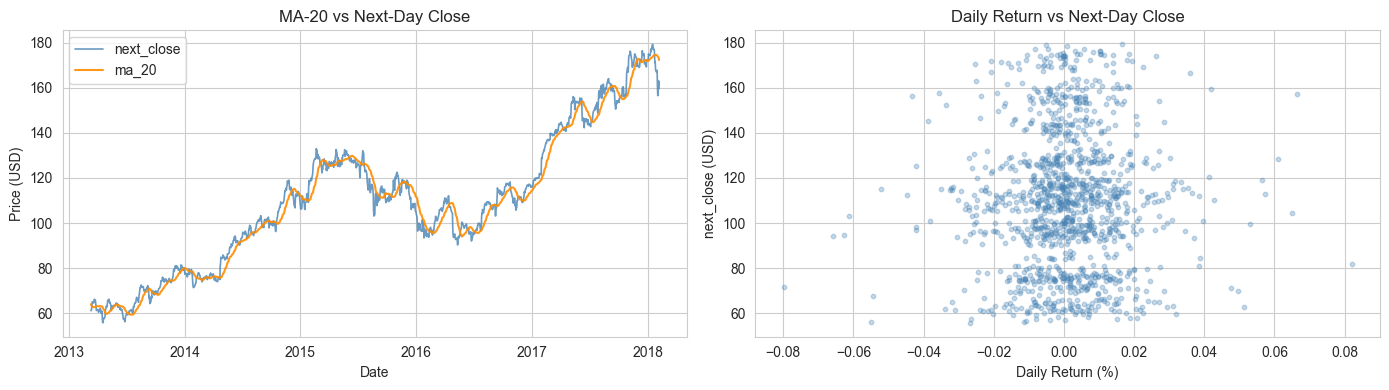

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# MA-20 vs next_close over time
axes[0].plot(aapl_clean['date'], aapl_clean['next_close'], label='next_close',
             color='steelblue', linewidth=1.2, alpha=0.8)
axes[0].plot(aapl_clean['date'], aapl_clean['ma_20'],     label='ma_20',
             color='darkorange', linewidth=1.5, alpha=0.9)
axes[0].set_title('MA-20 vs Next-Day Close'); axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (USD)'); axes[0].legend()

# daily_return vs next_close scatter
axes[1].scatter(aapl_clean['daily_return'], aapl_clean['next_close'],
                alpha=0.3, s=10, color='steelblue')
axes[1].set_title('Daily Return vs Next-Day Close')
axes[1].set_xlabel('Daily Return (%)'); axes[1].set_ylabel('next_close (USD)')

plt.tight_layout(); plt.show()

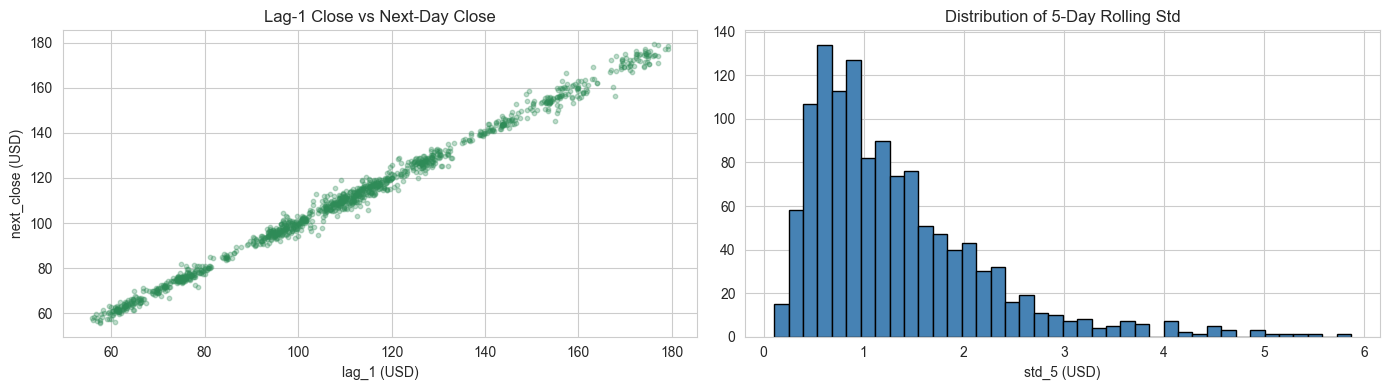

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# lag_1 vs next_close (should be near-perfect linear)
axes[0].scatter(aapl_clean['lag_1'], aapl_clean['next_close'],
                alpha=0.3, s=10, color='seagreen')
axes[0].set_title('Lag-1 Close vs Next-Day Close')
axes[0].set_xlabel('lag_1 (USD)'); axes[0].set_ylabel('next_close (USD)')

# std_5 vs |error| proxy: std_5 distribution
axes[1].hist(aapl_clean['std_5'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Distribution of 5-Day Rolling Std'); axes[1].set_xlabel('std_5 (USD)')

plt.tight_layout(); plt.show()

## 7. Save Cleaned Feature CSV

The cleaned dataset is written to `data/aapl_features.csv`. Notebook 03 reads this
file directly — no raw data processing is repeated there.

In [8]:
output_path = 'data/aapl_features.csv'
aapl_clean.to_csv(output_path, index=False)
print(f'Saved {len(aapl_clean)} rows to {output_path}')
print('Columns:', list(aapl_clean.columns))

Saved 1238 rows to data/aapl_features.csv
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'Name', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'ma_5', 'ma_10', 'ma_20', 'std_5', 'daily_return', 'volume_change', 'high_low_range', 'open_close_range', 'next_close']
